In [1]:
from langgraph.graph import StateGraph, START, END
from langchain_ollama import ChatOllama
import operator
from typing import TypedDict, Annotated
from pydantic import BaseModel, Field

In [2]:
model = ChatOllama(model="qwen2.5:3b")

In [3]:
class EvalSchema(BaseModel):

    feedback: str = Field(description='Detailed feedbackfor the essay')
    score: float = Field(description='Score out of 10', ge=0, le=10)

In [4]:
structured_model = model.with_structured_output(EvalSchema)

In [5]:
essay_text = """Literature is one of the most valuable forms of human expression, preserving ideas, emotions, and experiences across generations. It includes novels, poems, plays, essays, and short stories that reflect the beliefs, cultures, and traditions of different societies. Through literature, people gain knowledge about the past, understand the present, and imagine possibilities for the future. It is not merely a source of entertainment but also a powerful medium for education, self-discovery, and social change.
One of the primary reasons literature is important is that it helps us understand human nature. Every literary work explores emotions such as love, hope, fear, courage, and loss, allowing readers to connect with characters and situations that may be different from their own lives. This develops empathy and compassion, enabling people to appreciate diverse perspectives and cultures. By reading about the struggles and achievements of others, individuals become more open-minded and tolerant.
Literature also plays a significant role in improving language and communication skills. Reading regularly enhances vocabulary, grammar, sentence structure, and writing ability. It exposes readers to different styles of expression and encourages them to think creatively. Students, professionals, and lifelong learners all benefit from literature because it strengthens their ability to communicate effectively and confidently.
Another important aspect of literature is its contribution to critical thinking. Literary works often present complex characters, moral dilemmas, and thought-provoking themes that encourage readers to analyze situations, interpret meanings, and form independent opinions. Instead of accepting information at face value, readers learn to evaluate evidence, question assumptions, and appreciate multiple viewpoints. These analytical skills are valuable in education, careers, and everyday decision-making.
Furthermore, literature serves as a mirror of society. It reflects social, political, economic, and cultural issues of different periods, helping readers understand historical events and societal changes. Many literary works have inspired reforms by raising awareness about injustice, inequality, discrimination, and human rights. Writers often use literature as a tool to challenge harmful practices and inspire positive change, making it an influential force in shaping society.
Finally, literature enriches our personal lives by providing inspiration, comfort, and entertainment. Reading can reduce stress, stimulate imagination, and offer an escape from daily pressures. It encourages self-reflection and helps individuals discover values, purpose, and meaning in life.
In conclusion, literature is important because it educates, inspires, and connects people across cultures and generations. It develops language proficiency, critical thinking, empathy, and creativity while preserving the history and wisdom of humanity. By reading literature, individuals become more knowledgeable, compassionate, and thoughtful, making it an essential part of personal growth and the development of a better society.
"""

In [6]:
class EvalState(TypedDict):
    essay_text: str
    clarity_feedback: str
    analysis_feedback: str
    language_feedback: str
    overall_feedback: str
    individual_scores: Annotated[list[float], operator.add]
    final_score: float

In [7]:
def eval_clarity(state: EvalState):
    prompt = f"Evaluate the clarity of thought of the following essay, provide a feedback and assign a score out of 10: \n {state['essay_text']}"
    output = structured_model.invoke(prompt)

    return {'clarity_feedback': output.feedback, 'individual_scores': [output.score]}

In [8]:
def eval_analysis(state: EvalState):
    prompt = f"Evaluate the depth of analysis of the following essay, provide a feedback and assign a score out of 10: \n {state['essay_text']}"
    output = structured_model.invoke(prompt)

    return {'analysis_feedback': output.feedback, 'individual_scores': [output.score]}

In [9]:
def eval_language(state: EvalState):
    prompt = f"Evaluate the language quality of the following essay, provide a feedback and assign a score out of 10: \n {state['essay_text']}"
    output = structured_model.invoke(prompt)

    return {'language_feedback': output.feedback, 'individual_scores': [output.score]}

In [10]:
def final_eval(state: EvalState):
    prompt = f"Based on the following feedbacks create a summarized feedback: \n language feedback: {state['language_feedback']} \n depth of analysis feedback: {state['analysis_feedback']} \n clarity of thought feedback: {state['clarity_feedback']}"
    feedback = model.invoke(prompt).content

    score = sum(state['individual_scores']) / len(state['individual_scores'])

    return {'overall_feedback': feedback, 'final_score': score}

In [11]:
graph = StateGraph(EvalState)

graph.add_node('EvaluateClarity', eval_clarity)
graph.add_node('EvaluateAnalysis', eval_analysis)
graph.add_node('EvaluateLanguage', eval_language)
graph.add_node('FinalEvaluation', final_eval)

graph.add_edge(START, 'EvaluateClarity')
graph.add_edge(START, 'EvaluateAnalysis')
graph.add_edge(START, 'EvaluateLanguage')
graph.add_edge('EvaluateClarity', 'FinalEvaluation')
graph.add_edge('EvaluateAnalysis', 'FinalEvaluation')
graph.add_edge('EvaluateLanguage', 'FinalEvaluation')
graph.add_edge('FinalEvaluation', END)

workflow = graph.compile()

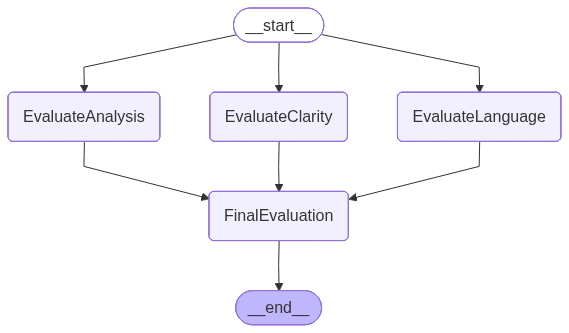

In [12]:
workflow

In [13]:
initial_state = {'essay_text': essay_text}

final_state = workflow.invoke(initial_state)

In [14]:
final_state

{'essay_text': 'Literature is one of the most valuable forms of human expression, preserving ideas, emotions, and experiences across generations. It includes novels, poems, plays, essays, and short stories that reflect the beliefs, cultures, and traditions of different societies. Through literature, people gain knowledge about the past, understand the present, and imagine possibilities for the future. It is not merely a source of entertainment but also a powerful medium for education, self-discovery, and social change.\nOne of the primary reasons literature is important is that it helps us understand human nature. Every literary work explores emotions such as love, hope, fear, courage, and loss, allowing readers to connect with characters and situations that may be different from their own lives. This develops empathy and compassion, enabling people to appreciate diverse perspectives and cultures. By reading about the struggles and achievements of others, individuals become more open-m